<a href="https://colab.research.google.com/github/vlhsilvia/TRABAJOS-PRACTICOS/blob/Silviamaster/C_Geotaller6_BuffersAnalisisEspacial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Geotaller 6: Dibujando Fronteras: Buffers y Análisis Espacial con Python

🎯 **Objetivo del Geotaller**

1. En este taller vamos a aprender a analizar buffers en Python aplicando las mismas metodologías utilizadas en software Desktop de GIS (e.g. QGIS y Arcgis Pro).
2. Vamos a estar utilizando *buffers* en puntos y líneas para evaluar zonas de influencia en infraestructura educativa, movilidad y establecimientos comerciales en Medellín, Colombia.

##1. Introducción a los Buffers

Con qué finalidad hacemos uso de los Buffers? **Un buffer crea un área alrededor de una geometría a una distancia específica.**. Lo usamos con el fin de medir zonas de influencia, accesibilidad y riesgo.


📖 Referencias QGIS Aplicadas en Python

[Basado en la documentación de QGIS](https://docs.qgis.org/3.40/es/docs/gentle_gis_introduction/vector_spatial_analysis_buffers.html):

La documentación de QGIS define buffers como herramientas clave para:

* Modelar accesibilidad y zonas de influencia.
* Delimitar áreas de impacto de infraestructura.
* Evaluar proximidad entre elementos geográficos.

**Implementaremos estos conceptos teóricos en Python con GeoPandas y Shapely.**

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

!pip install contextily
import contextily as ctx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 41.3 MB/s eta 0:00:00


##2. Cargar y Explorar los Datos

1. [Dataset sedes educativas](https://www.medellin.gov.co/geomedellin/datosAbiertos/1035)
2. [Dataset Vías exentas de pico y placa](https://www.medellin.gov.co/geomedellin/datosAbiertos/1869)
3. [Establecimientos comerciales](https://www.medellin.gov.co/geomedellin/datosAbiertos/1024)

In [ ]:
path1 = "/content/geojson_sedes_educativas.zip"
path2 = "/content/geojson_vias_exentas_de_pico_y_pl.zip"
path3 = '/content/geojson_establecimientos_de_indus.zip'

In [ ]:
# Cargar datasets
educacion = gpd.read_file(path1)
vias = gpd.read_file(path2)
establecimientos = gpd.read_file(path3)


In [ ]:
#Verificamos los dataFrames
educacion.tail(3)

,OBJECTID,nombre_establecimiento,sede_educativa,nucleo,servicio,sector,direccion,telefono,estado,vigencia,...,cons_sede,dane_sede,longitud,latitud,cbml,codigo_comuna,nombre_comuna,codigo_barrio,nombre_barrio,geometry
776,777,Centro Educativo Caimpa,Centro Educativo Caimpa,925,No Oficial,No Oficial,Carrera 27 # 48-81,6044999623,Activo,2024,...,30500180042201,305001800422,-75.550659,6.239374,09080370017,09,Buenos Aires,0908,Miraflores,POINT (4717866.838 2248122.015)
777,778,Colegio Belen Campestre,Colegio Belen Campestre,935,No Oficial,No Oficial,KR 93 A # 6 SUR 65,3153849777,Activo,2024,...,40500180043501,405001800435,-75.619151,6.204211,70010000443,70,Altavista,7008,El Jardín,POINT (4710266.505 2244269.776)
778,779,Jardin Infantil Capullos De Seda,Jardin Infantil Capullos De Seda,937,No Oficial,No Oficial,CL 10 3 19,2815975,Activo,2024,...,40500102538401,405001025384,NaN,NaN,80004360034,80,San Antonio de Prado,AUC2,San Antonio de Prado,POINT (4706896.766 2241896.444)


In [ ]:
vias.tail(3)

,OBJECTID,via,nombre_via,detalle,Shape_Length,geometry
65,66,,,,72.920857,"LINESTRING (4714939.772 2248168.391, 4714866.8..."
66,67,,,,44.053269,"LINESTRING (4714854.857 2248165.654, 4714816.1..."
67,68,,,,30.661227,"LINESTRING (4715399.192 2250420.632, 4715398.7..."


In [ ]:
establecimientos.tail(3)

,OBJECTID,id_contrato,nombre_establecimiento,corregimiento,codigociiu,grupo_actividad,comuna,nombre_comuna,codigo_barrio,nombre_barrio,longitud,latitud,x_origen_nacional,y_origen_nacional,geometry
438517,438518,00000000000001932689,WELLNESS LIFE SPA,12,9609,03,None,SAN JAVIER,1312,Betania,-75.620984,6.245403,4.710086e+06,2.248827e+06,POINT (4710086.111 2248827.155)
438518,438519,00000000000001932690,MOFLESLARGO,16,4520,03,None,BELEN,1601,Fï¿½tima,-75.582850,6.234205,4.714301e+06,2.247568e+06,POINT (4714300.964 2247567.606)
438519,438520,00000000000001932691,CREACIONES ZEUS GENESIS,07,4719,02,None,ROBLEDO,0712,Aures No. 2,-75.590684,6.293475,4.713466e+06,2.254128e+06,POINT (4713466.207 2254127.756)


Ahora los tipos de atributo y el # de registros

In [ ]:
educacion.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 779 entries, 0 to 778
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   OBJECTID                779 non-null    int32   
 1   nombre_establecimiento  779 non-null    object  
 2   sede_educativa          779 non-null    object  
 3   nucleo                  779 non-null    object  
 4   servicio                779 non-null    object  
 5   sector                  779 non-null    object  
 6   direccion               779 non-null    object  
 7   telefono                779 non-null    object  
 8   estado                  779 non-null    object  
 9   vigencia                779 non-null    object  
 10  x_origen_nacional       779 non-null    float64 
 11  y_origen_nacional       779 non-null    float64 
 12  clasificacion           779 non-null    object  
 13  codigo_dane             779 non-null    object  
 14  cons_sede         

In [ ]:
establecimientos.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 438520 entries, 0 to 438519
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype   
---  ------                  --------------   -----   
 0   OBJECTID                438520 non-null  int32   
 1   id_contrato             438520 non-null  object  
 2   nombre_establecimiento  438514 non-null  object  
 3   corregimiento           438520 non-null  object  
 4   codigociiu              436961 non-null  object  
 5   grupo_actividad         438453 non-null  object  
 6   comuna                  217566 non-null  object  
 7   nombre_comuna           438520 non-null  object  
 8   codigo_barrio           438520 non-null  object  
 9   nombre_barrio           438520 non-null  object  
 10  longitud                438520 non-null  float64 
 11  latitud                 438520 non-null  float64 
 12  x_origen_nacional       438520 non-null  float64 
 13  y_origen_nacional       438520 non-null  float64 
 

In [ ]:
# Filtrar establecimientos por código CIIU
codigos_ciiu_alcohol = ['5611', '5612', '5613', '5630']
establecimientos_alcohol = establecimientos[establecimientos['codigociiu'].isin(codigos_ciiu_alcohol)]
#Resetea el index
establecimientos_alcohol = establecimientos_alcohol.reset_index(drop=True)

In [ ]:
print(f"Total de establecimientos comerciales: {establecimientos.shape[0]}")
print(f"Total de establecimientos comerciales en Áreas de Alcohol: {establecimientos_alcohol.shape[0]}")

Total de establecimientos comerciales: 438520
Total de establecimientos comerciales en Áreas de Alcohol: 31350


In [ ]:
vias.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   OBJECTID      68 non-null     int32   
 1   via           68 non-null     object  
 2   nombre_via    68 non-null     object  
 3   detalle       68 non-null     object  
 4   Shape_Length  68 non-null     float64 
 5   geometry      68 non-null     geometry
dtypes: float64(1), geometry(1), int32(1), object(3)
memory usage: 3.1+ KB


y el sistema de coordenadas

In [ ]:
geodata = [educacion, vias, establecimientos_alcohol]
for i in geodata:
  print(i.crs)

EPSG:9377
EPSG:9377
EPSG:9377


<Axes: >

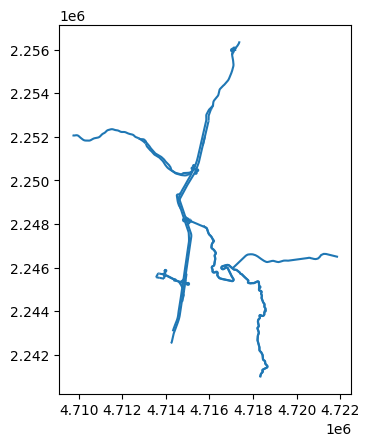

In [ ]:
vias.plot()

<Axes: >

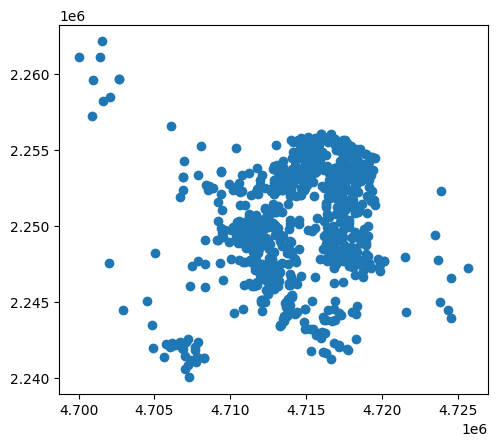

In [ ]:
educacion.plot()

<Axes: >

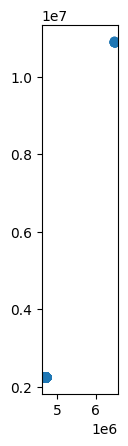

In [ ]:
establecimientos_alcohol.plot()

In [ ]:
#Determina el total_bounds de educacion
educacion.total_bounds

array([4700006.1014, 2240025.5067, 4725683.3817, 2262168.4184])

In [ ]:
establecimientos_med = establecimientos_alcohol.cx[4700006.1014:4725683.3817, 2240025.5067:2262168.4184]

<Axes: >

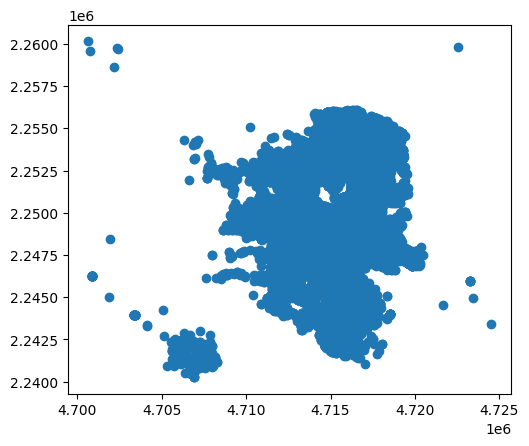

In [ ]:
establecimientos_med.plot()

Ahora podemos dibujar los tres geodataFrames

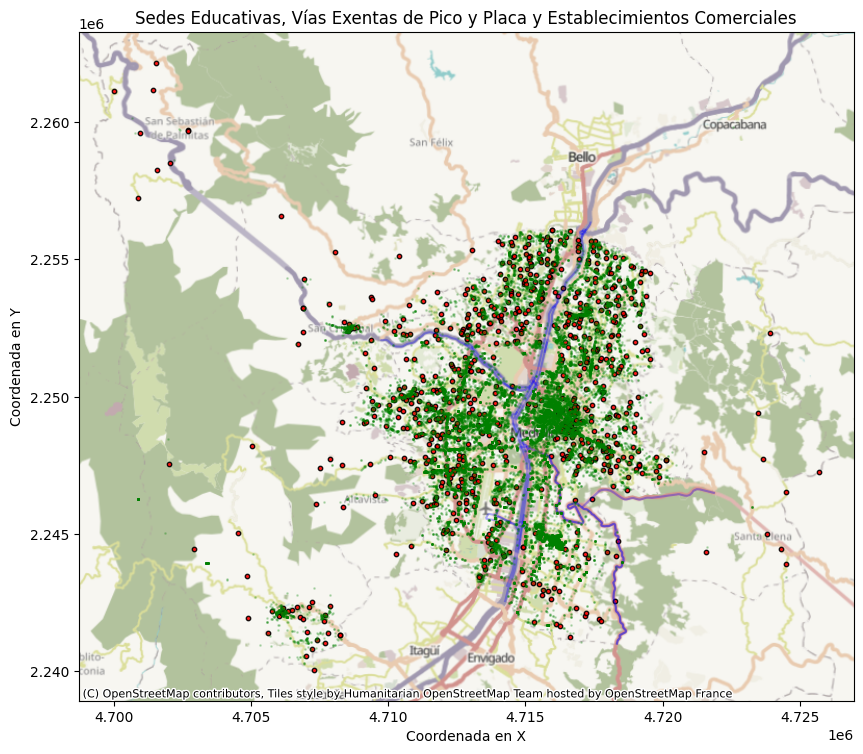

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
educacion.plot(ax=ax, color='red', alpha=0.9, edgecolor='black', markersize=10, zorder=1)
vias.plot(ax=ax, color='blue', alpha=0.3, edgecolor='black', markersize=4, zorder=2)
establecimientos_med.plot(ax=ax, color='green', alpha=0.2, markersize=1, zorder=3)
ctx.add_basemap(ax=ax, crs=educacion.crs.to_string())
ax.set_title('Sedes Educativas, Vías Exentas de Pico y Placa y Establecimientos Comerciales')
ax.set_xlabel('Coordenada en X')
ax.set_ylabel('Coordenada en Y')
plt.show()

##3. Creación de Buffers en Puntos y Líneas



***Buffers* alrededor de sedes educativas**

In [ ]:
# Crear buffers de 200m para los colegios
educacion['buffer_200m'] = educacion.buffer(200)

In [ ]:
educacion.tail()

,OBJECTID,nombre_establecimiento,sede_educativa,nucleo,servicio,sector,direccion,telefono,estado,vigencia,...,dane_sede,longitud,latitud,cbml,codigo_comuna,nombre_comuna,codigo_barrio,nombre_barrio,geometry,buffer_200m
774,775,Cosmo Schools - Sede Hospital San Vicente De Paul,Cosmo Schools - Sede Hospital San Vicente De Paul,927,No Oficial,No Oficial,CL 64 51 D 154 BQ 1,5212929 - 310 3016666,Activo,2024,...,305001800406,-75.564285,6.263440,10020010001,10,La Candelaria,Inst_12,Hospital San Vicente de Paúl,POINT (4716371.635 2250791.244),"POLYGON ((4716571.635 2250791.244, 4716570.672..."
775,776,Cosmo School Sede Candelaria,Cosmo School Sede Candelaria,928,No Oficial,No Oficial,CL 47 43 48,5212929 - 310 3016666,Activo,2024,...,305001800414,-75.564739,6.244808,10190010024,10,La Candelaria,1019,La Candelaria,POINT (4716311.392 2248730.644),"POLYGON ((4716511.392 2248730.644, 4716510.429..."
776,777,Centro Educativo Caimpa,Centro Educativo Caimpa,925,No Oficial,No Oficial,Carrera 27 # 48-81,6044999623,Activo,2024,...,305001800422,-75.550659,6.239374,09080370017,09,Buenos Aires,0908,Miraflores,POINT (4717866.838 2248122.015),"POLYGON ((4718066.838 2248122.015, 4718065.875..."
777,778,Colegio Belen Campestre,Colegio Belen Campestre,935,No Oficial,No Oficial,KR 93 A # 6 SUR 65,3153849777,Activo,2024,...,405001800435,-75.619151,6.204211,70010000443,70,Altavista,7008,El Jardín,POINT (4710266.505 2244269.776),"POLYGON ((4710466.505 2244269.776, 4710465.542..."
778,779,Jardin Infantil Capullos De Seda,Jardin Infantil Capullos De Seda,937,No Oficial,No Oficial,CL 10 3 19,2815975,Activo,2024,...,405001025384,NaN,NaN,80004360034,80,San Antonio de Prado,AUC2,San Antonio de Prado,POINT (4706896.766 2241896.444),"POLYGON ((4707096.766 2241896.444, 4707095.803..."


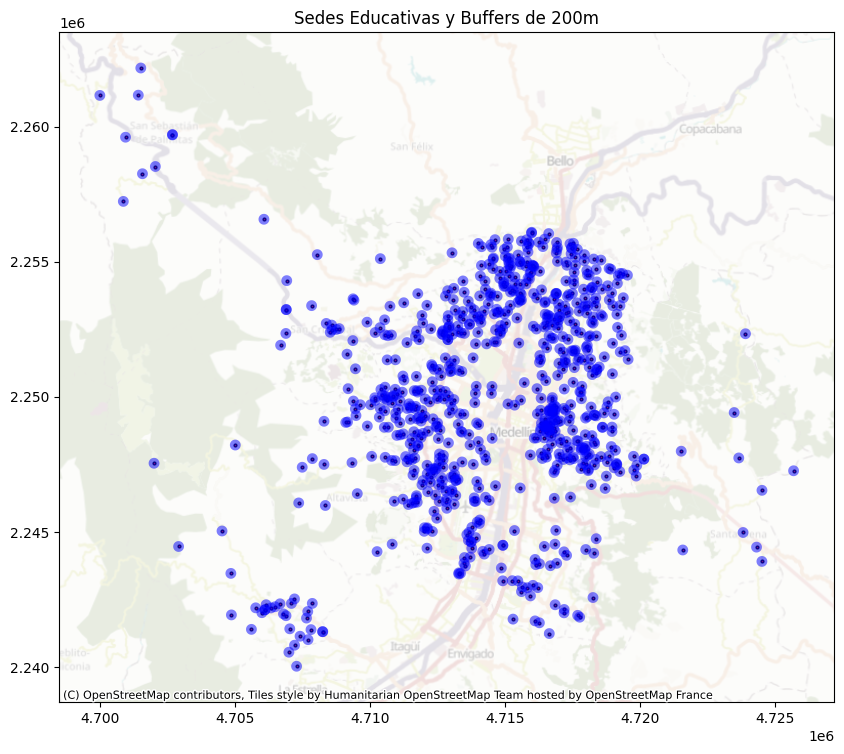

In [ ]:
#Visualizamos el geodataFrame junto con su valor de buffer
fig, ax3 = plt.subplots(figsize=(10,10))
educacion.plot(ax=ax3, color='red', alpha=0.9, edgecolor='black', markersize=4)
educacion['buffer_200m'].plot(ax=ax3, color='blue', alpha=0.5)
ctx.add_basemap(ax=ax3, crs=educacion.crs.to_string(), alpha=0.3)
ax3.set_title('Sedes Educativas y Buffers de 200m')
plt.show()

Podemos hacer un *zoom*:  [Atributo cx[] de geopandas](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.cx.html)

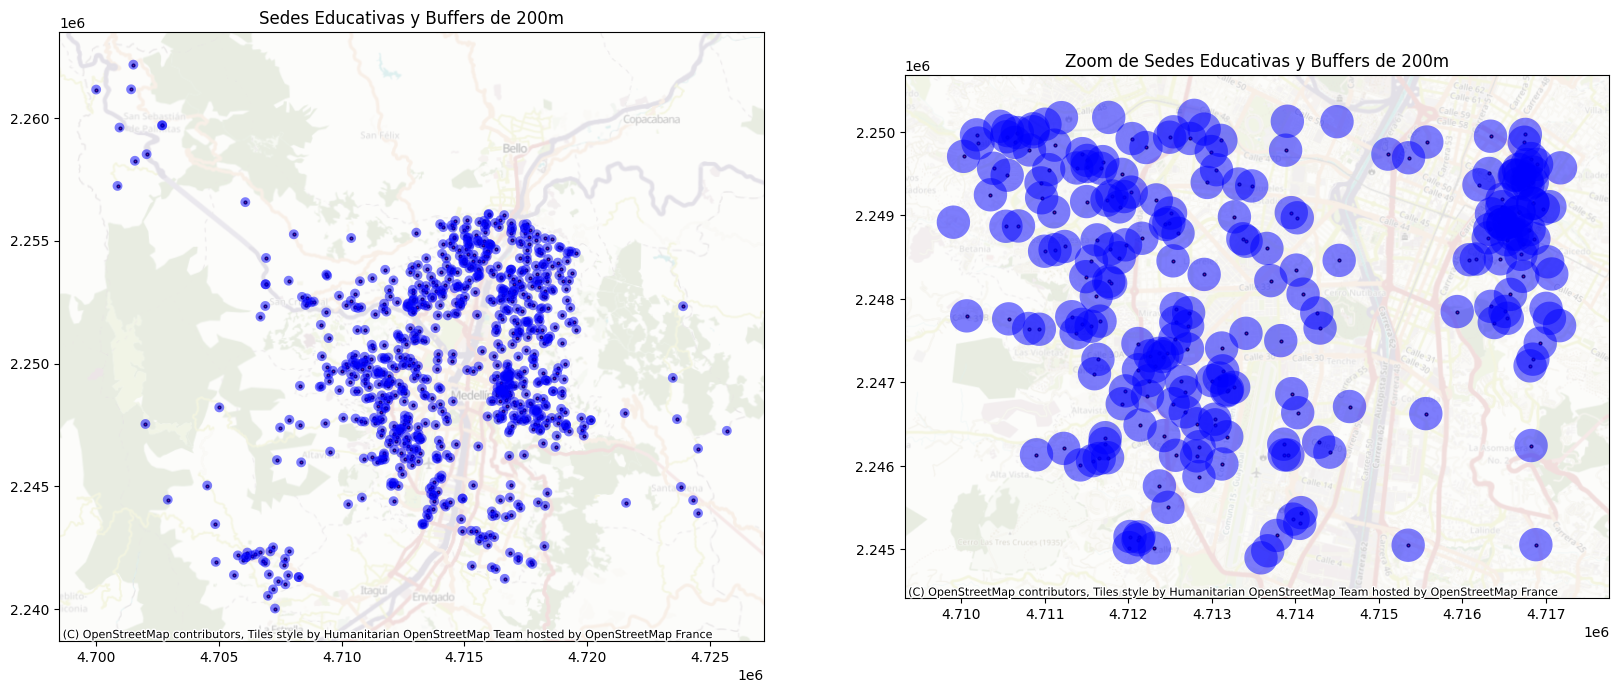

In [ ]:
fig, (ax2, ax3) = plt.subplots(1, 2, figsize=(20, 20))
educacion.plot(ax=ax2, color='red', alpha=0.9, edgecolor='black', markersize=4)
educacion['buffer_200m'].plot(ax=ax2, color='blue', alpha=0.5)
ax2.set_title('Sedes Educativas y Buffers de 200m')
ctx.add_basemap(ax=ax2, crs=educacion.crs.to_string(), alpha=0.3)

# Zoom
educacion.cx[4710000:4717000, 2245000:2250000].plot(ax=ax3, color='red', alpha=0.9, edgecolor='black', markersize=4)
educacion['buffer_200m'].cx[4710000:4717000, 2245000:2250000].plot(ax=ax3, color='blue', alpha=0.5)
ctx.add_basemap(ax=ax3, crs=educacion.crs.to_string(), alpha=0.3)
ax3.set_title('Zoom de Sedes Educativas y Buffers de 200m')
plt.show()

**¿Qué representa este buffer?**

- Zona de cobertura de cada colegio en 200m. Similar a herramientas de proximidad en QGIS.

***Buffers* alrededor de carreteras(líneas)**

In [ ]:
# Crear buffers de 50m para las vías
vias['buffer_50m'] = vias.buffer(50)

In [ ]:
vias.tail()

,OBJECTID,via,nombre_via,detalle,Shape_Length,geometry,buffer_50m
63,64,,,,14.616684,"LINESTRING (4714954.382 2248168.832, 4714946.2...","POLYGON ((4714947.766 2248118.623, 4714941.384..."
64,65,,,,12.038944,"LINESTRING (4714866.889 2248166.041, 4714854.8...","POLYGON ((4714856.467 2248115.68, 4714851.561 ..."
65,66,,,,72.920857,"LINESTRING (4714939.772 2248168.391, 4714866.8...","POLYGON ((4714868.5 2248116.067, 4714863.594 2..."
66,67,,,,44.053269,"LINESTRING (4714854.857 2248165.654, 4714816.1...","POLYGON ((4714817.72 2248114.431, 4714813.006 ..."
67,68,,,,30.661227,"LINESTRING (4715399.192 2250420.632, 4715398.7...","POLYGON ((4715358.159 2250392.053, 4715340.691..."


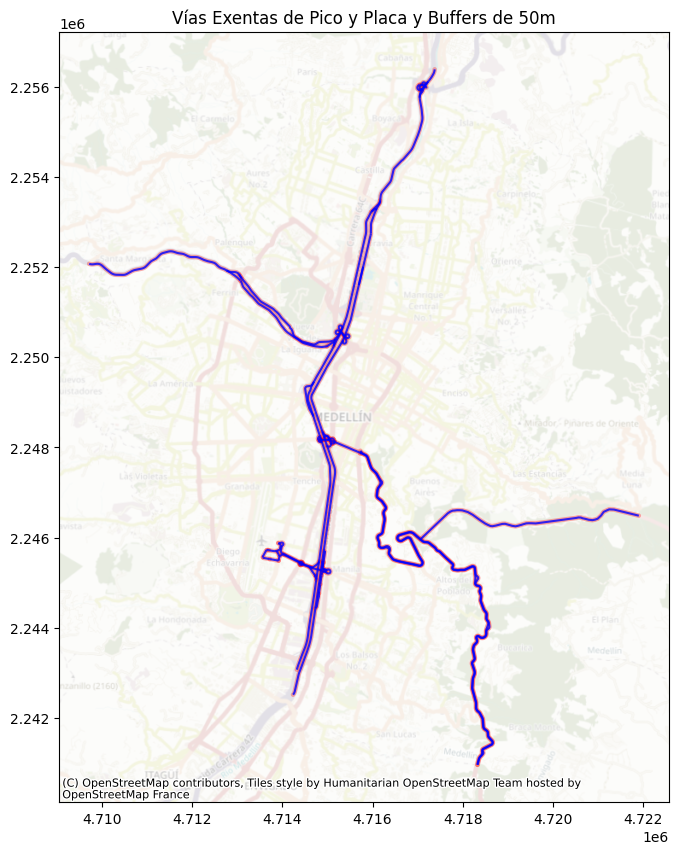

In [ ]:
#Visualizamos el geodataFrame junto con su valor de buffer
fig, ax4 = plt.subplots(figsize=(10,10))
vias.plot(ax=ax4, color='blue', alpha=0.8, edgecolor='black', markersize=1)
vias['buffer_50m'].plot(ax=ax4, color='red', alpha=0.3)
ctx.add_basemap(ax=ax4, crs=vias.crs.to_string(), alpha=0.3)
ax4.set_title('Vías Exentas de Pico y Placa y Buffers de 50m')
plt.show()

Podemos hacer un *zoom*

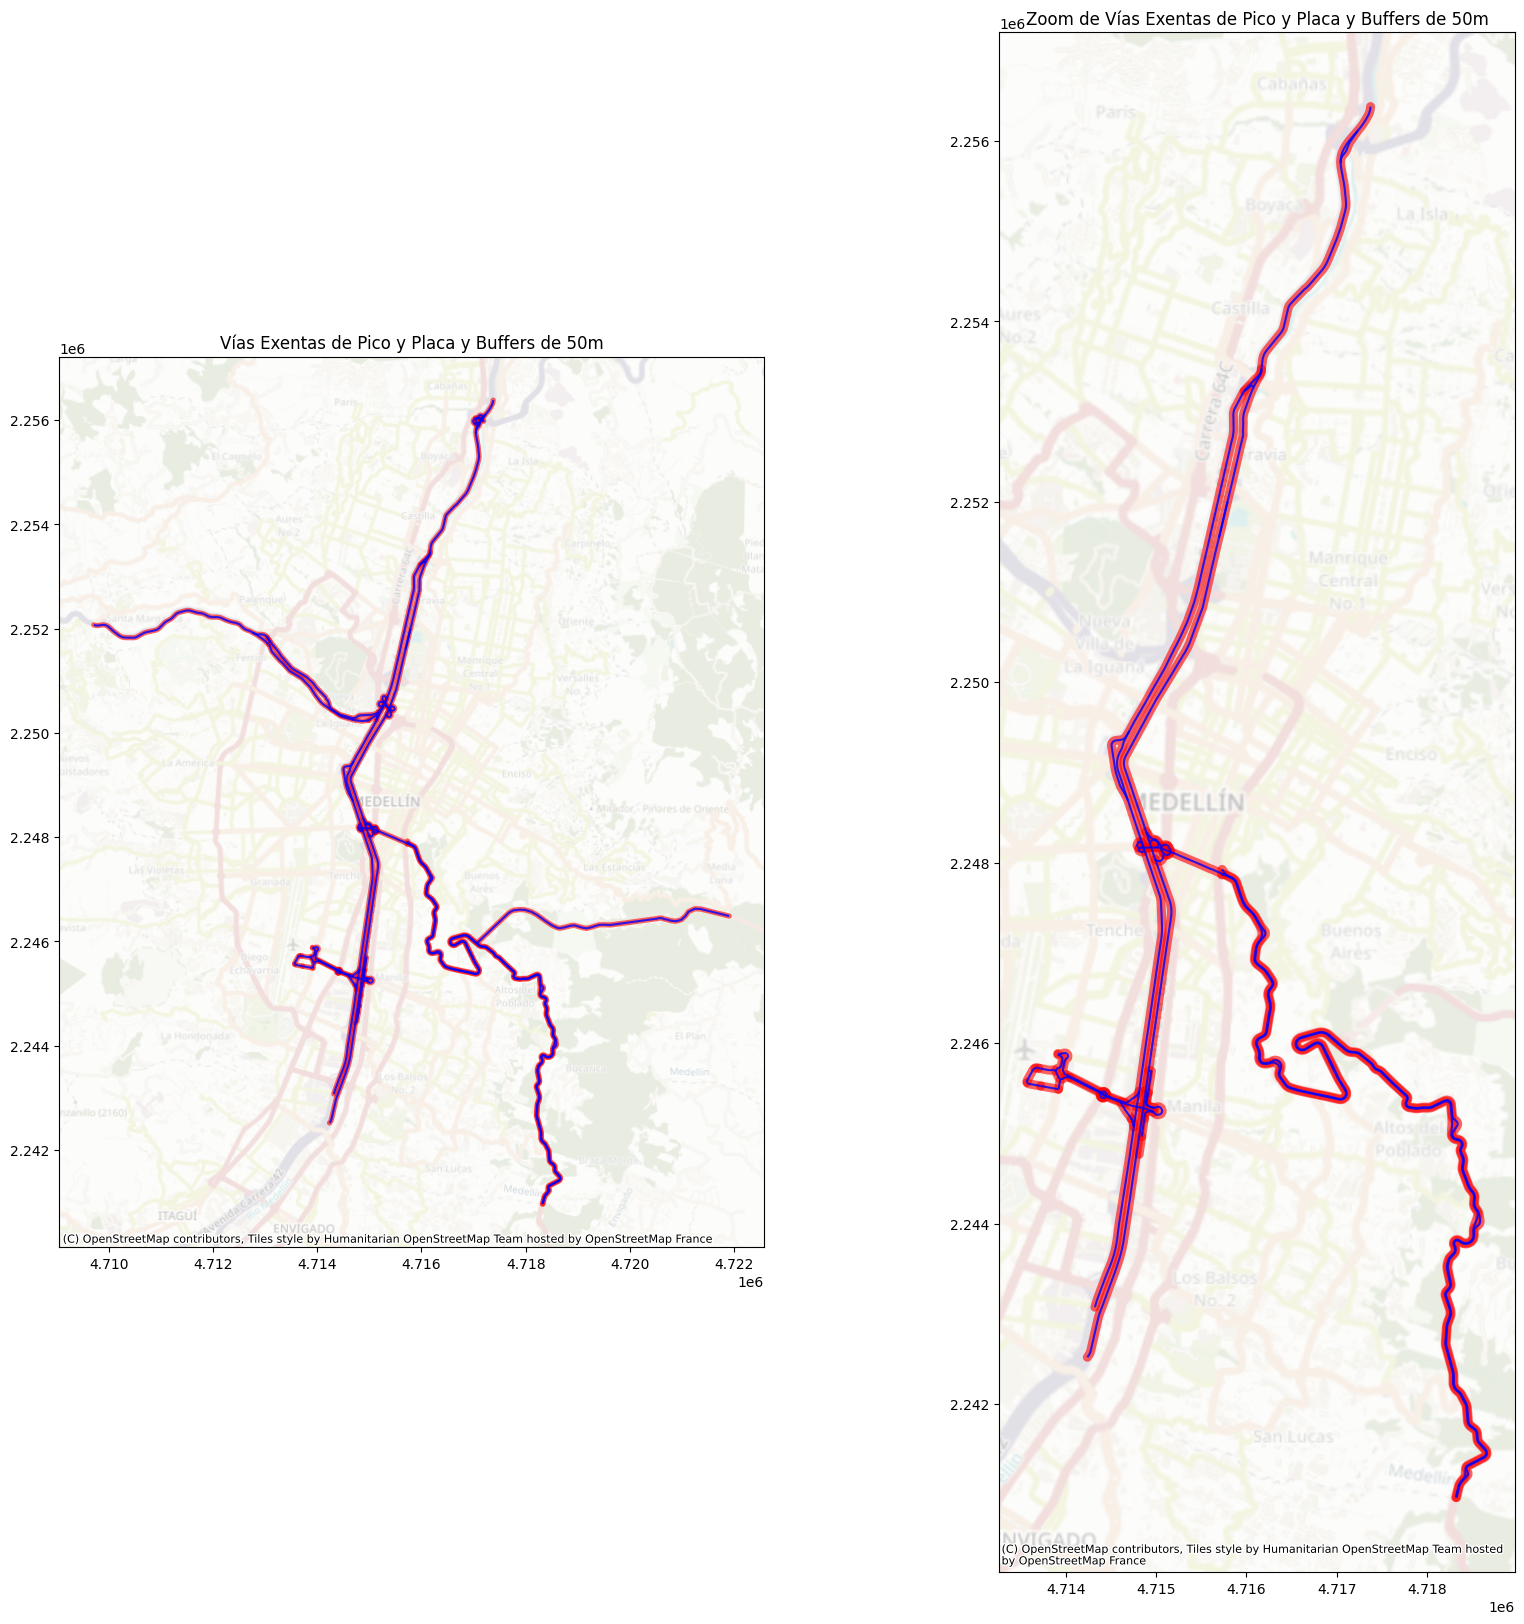

In [ ]:
fig, (ax5, ax6) = plt.subplots(1, 2, figsize=(20, 20))
vias.plot(ax=ax5, color='blue', alpha=0.8, edgecolor='black', markersize=1)
vias['buffer_50m'].plot(ax=ax5, color='red', alpha=0.6)
#Visualiza ambos dataFrames
vias.cx[4710000:4717000, 2245000:2250000].plot(ax=ax6, color='blue', alpha=0.8, edgecolor='black', markersize=1)
vias['buffer_50m'].cx[4710000:4717000, 2245000:2250000].plot(ax=ax6, color='red', alpha=0.6)
ctx.add_basemap(ax=ax5, crs=vias.crs.to_string(), alpha=0.3)
ctx.add_basemap(ax=ax6, crs=vias.crs.to_string(), alpha=0.3)
ax5.set_title('Vías Exentas de Pico y Placa y Buffers de 50m')
ax6.set_title('Zoom de Vías Exentas de Pico y Placa y Buffers de 50m')
plt.show()


**¿Qué representa este buffer?**

- Zonas de impacto de carreteras en barrios cercanos.

**Ahora visualicemos**

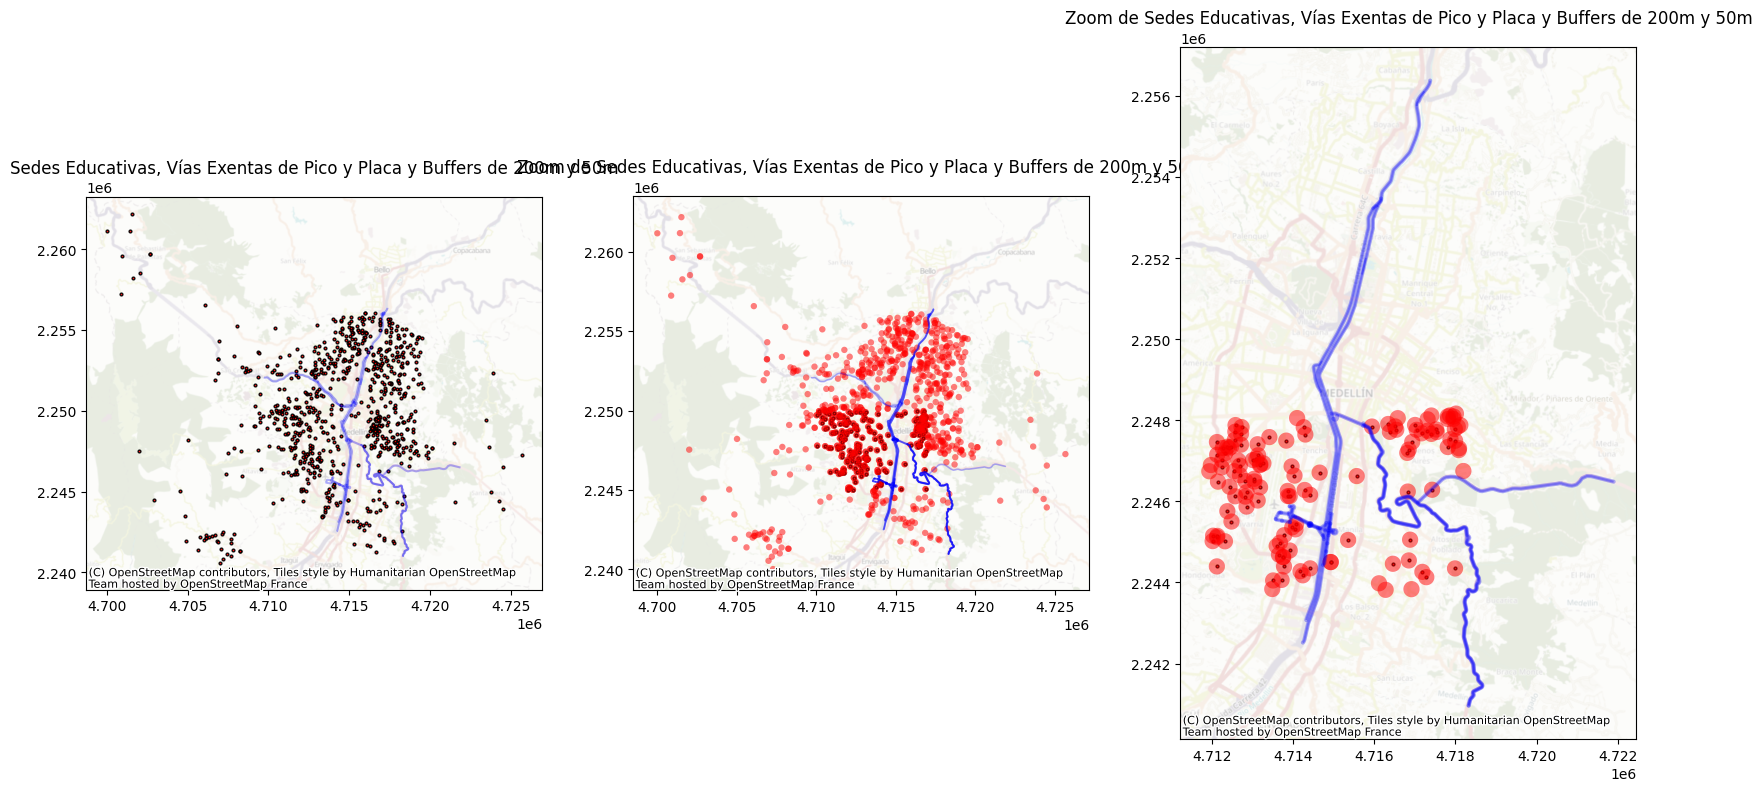

In [ ]:
fig, (ax7, ax8, ax9) = plt.subplots(1, 3, figsize=(20, 20))
educacion.plot(ax=ax7, color='red', alpha=0.9, edgecolor='black', markersize=4)
vias.plot(ax=ax7, color='blue', alpha=0.3, edgecolor='black', markersize=1)
educacion['buffer_200m'].plot(ax=ax8, color='red', alpha=0.5)
vias['buffer_50m'].plot(ax=ax8, color='blue', alpha=0.3)
ax7.set_title('Sedes Educativas, Vías Exentas de Pico y Placa y Buffers de 200m y 50m')
ctx.add_basemap(ax=ax7, crs=educacion.crs.to_string(), alpha=0.3)

#Ahora sobre el zoom
educacion.cx[4710000:4717000, 2245000:2250000].plot(ax=ax8, color='red', alpha=0.9, edgecolor='black', markersize=4)
vias.cx[4710000:4717000, 2245000:2250000].plot(ax=ax8, color='blue', alpha=0.3, edgecolor='black', markersize=1)
educacion['buffer_200m'].cx[4710000:4717000, 2245000:2250000].plot(ax=ax8, color='red', alpha=0.5)
vias['buffer_50m'].cx[4710000:4717000, 2245000:2250000].plot(ax=ax8, color='blue', alpha=0.3)
ax8.set_title('Zoom de Sedes Educativas, Vías Exentas de Pico y Placa y Buffers de 200m y 50m')
ctx.add_basemap(ax=ax8, crs=educacion.crs.to_string(), alpha=0.3)

#Aumentemos el zoom
educacion.cx[4712000:4718000, 2244000:2248000].plot(ax=ax9, color='red', alpha=0.9, edgecolor='black', markersize=4)
vias.cx[4712000:4718000, 2244000:2248000].plot(ax=ax9, color='blue', alpha=0.3, edgecolor='black', markersize=1)
educacion['buffer_200m'].cx[4712000:4718000, 2244000:2248000].plot(ax=ax9, color='red', alpha=0.5)
vias['buffer_50m'].cx[4712000:4718000, 2244000:2248000].plot(ax=ax9, color='blue', alpha=0.3)
ax9.set_title('Zoom de Sedes Educativas, Vías Exentas de Pico y Placa y Buffers de 200m y 50m')
ctx.add_basemap(ax=ax9, crs=educacion.crs.to_string(), alpha=0.3)


plt.show()

¿Cuántos colegios están en áreas de impacto de carreteras?

[Método *overlay*, de geopandas](https://geopandas.org/en/stable/docs/user_guide/set_operations.html)

In [ ]:
intersecta = educacion.set_geometry('buffer_200m').overlay(vias.set_geometry('buffer_50m'), how='intersection')

#Resetea index
intersecta = intersecta.reset_index(drop=True)

print(f"Total de colegios en zonas viales críticas: {intersecta.shape[0]}")


Total de colegios en zonas viales críticas: 63


In [ ]:
intersecta.tail()

,OBJECTID_1,nombre_establecimiento,sede_educativa,nucleo,servicio,sector,direccion,telefono,estado,vigencia,...,codigo_barrio,nombre_barrio,geometry_1,OBJECTID_2,via,nombre_via,detalle,Shape_Length,geometry_2,geometry
58,732,Centro Educativo Pequeños Triunfadores,Centro Educativo Pequeños Triunfadores,927,No Oficial,No Oficial,CL 61 A 55 A 66,5133332,Activo,2024,...,1004,El Chagualo,POINT (4715713.162 2250527.249),8,,Puente Horacio Toro E-W,Calzada Oriente-Occidente Puente Horacio Toro ...,1313.870949,"MULTILINESTRING ((4715154.92 2250336.632, 4715...","POLYGON ((4715528.386 2250450.712, 4715521.774..."
59,764,El Colegio,El Colegio,932,No Oficial,No Oficial,"Kilómetro 7, vía las Palmas",2660678,Activo,2024,...,9001,Las Palmas,POINT (4718376.952 2244747.05),3,Av. Las Palmas,Av. Las Palmas N,Hasta el empalme con glorieta de San Diego,11968.764532,"LINESTRING (4718330.613 2240961.585, 4718358.1...","POLYGON ((4718453.488 2244562.274, 4718435.009..."
60,764,El Colegio,El Colegio,932,No Oficial,No Oficial,"Kilómetro 7, vía las Palmas",2660678,Activo,2024,...,9001,Las Palmas,POINT (4718376.952 2244747.05),4,Av. Las Palmas,Av. Las Palmas S,Hasta el empalme con glorieta de San Diego,11804.265419,"LINESTRING (4718320.931 2240964.014, 4718349.3...","POLYGON ((4718453.488 2244562.274, 4718435.009..."
61,774,Colegio Destino (Destiny School),Colegio Destino (Destiny School),926,No Oficial,No Oficial,CL 19 A 27 250,3142734642 - 3203521744,Activo,2024,...,9001,Las Palmas,POINT (4716824.483 2246242.831),3,Av. Las Palmas,Av. Las Palmas N,Hasta el empalme con glorieta de San Diego,11968.764532,"LINESTRING (4718330.613 2240961.585, 4718358.1...","MULTIPOLYGON (((4716965.904 2246101.409, 47169..."
62,774,Colegio Destino (Destiny School),Colegio Destino (Destiny School),926,No Oficial,No Oficial,CL 19 A 27 250,3142734642 - 3203521744,Activo,2024,...,9001,Las Palmas,POINT (4716824.483 2246242.831),4,Av. Las Palmas,Av. Las Palmas S,Hasta el empalme con glorieta de San Diego,11804.265419,"LINESTRING (4718320.931 2240964.014, 4718349.3...","POLYGON ((4716951.362 2246088.229, 4716935.597..."


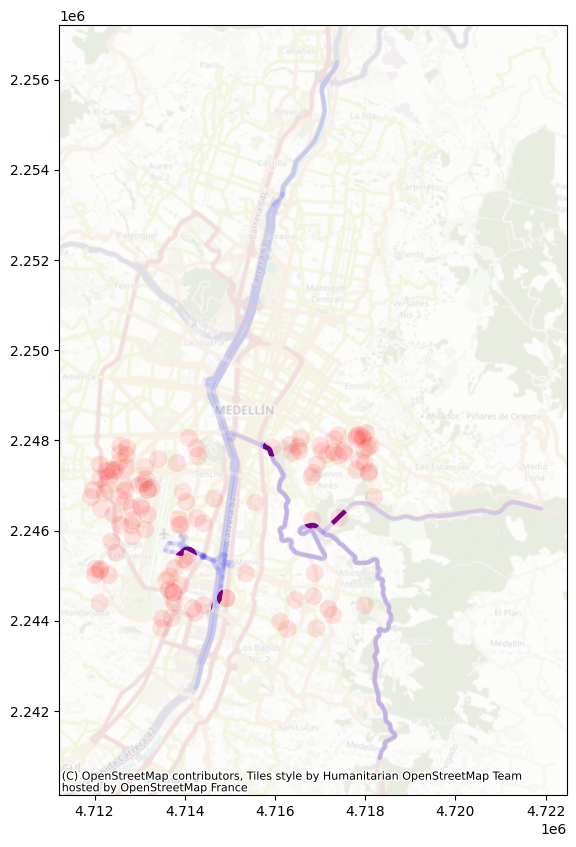

In [ ]:
fig, ax11 = plt.subplots(figsize=(10,10))
intersecta.cx[4712000:4718000, 2244000:2248000].plot(ax=ax11, color='purple', alpha=1.0, zorder=1)
educacion['buffer_200m'].cx[4712000:4718000, 2244000:2248000].plot(ax=ax11, color='red', alpha=0.1, zorder=1)
vias['buffer_50m'].cx[4712000:4718000, 2244000:2248000].plot(ax=ax11, color='blue', alpha=0.1, zorder=2)
ctx.add_basemap(ax=ax11, crs=educacion.crs.to_string(), alpha=0.3)


**Ejercicio Adicional**

En muchas ciudades existe una normativa que prohíbe la venta de alcohol dentro de cierta distancia de escuelas, colegios y universidades. Vamos a usar análisis de buffers para:

* Identificar qué establecimientos incumplen esta norma
* Ayudar a la planificación de nuevos locales comerciales
* Apoyar la toma de decisiones en políticas públicas

In [ ]:
educacion['Buffer_100m'] = educacion.buffer(100)
educacion.tail()

,OBJECTID,nombre_establecimiento,sede_educativa,nucleo,servicio,sector,direccion,telefono,estado,vigencia,...,longitud,latitud,cbml,codigo_comuna,nombre_comuna,codigo_barrio,nombre_barrio,geometry,buffer_200m,Buffer_100m
774,775,Cosmo Schools - Sede Hospital San Vicente De Paul,Cosmo Schools - Sede Hospital San Vicente De Paul,927,No Oficial,No Oficial,CL 64 51 D 154 BQ 1,5212929 - 310 3016666,Activo,2024,...,-75.564285,6.263440,10020010001,10,La Candelaria,Inst_12,Hospital San Vicente de Paúl,POINT (4716371.635 2250791.244),"POLYGON ((4716571.635 2250791.244, 4716570.672...","POLYGON ((4716471.635 2250791.244, 4716471.153..."
775,776,Cosmo School Sede Candelaria,Cosmo School Sede Candelaria,928,No Oficial,No Oficial,CL 47 43 48,5212929 - 310 3016666,Activo,2024,...,-75.564739,6.244808,10190010024,10,La Candelaria,1019,La Candelaria,POINT (4716311.392 2248730.644),"POLYGON ((4716511.392 2248730.644, 4716510.429...","POLYGON ((4716411.392 2248730.644, 4716410.911..."
776,777,Centro Educativo Caimpa,Centro Educativo Caimpa,925,No Oficial,No Oficial,Carrera 27 # 48-81,6044999623,Activo,2024,...,-75.550659,6.239374,09080370017,09,Buenos Aires,0908,Miraflores,POINT (4717866.838 2248122.015),"POLYGON ((4718066.838 2248122.015, 4718065.875...","POLYGON ((4717966.838 2248122.015, 4717966.356..."
777,778,Colegio Belen Campestre,Colegio Belen Campestre,935,No Oficial,No Oficial,KR 93 A # 6 SUR 65,3153849777,Activo,2024,...,-75.619151,6.204211,70010000443,70,Altavista,7008,El Jardín,POINT (4710266.505 2244269.776),"POLYGON ((4710466.505 2244269.776, 4710465.542...","POLYGON ((4710366.505 2244269.776, 4710366.023..."
778,779,Jardin Infantil Capullos De Seda,Jardin Infantil Capullos De Seda,937,No Oficial,No Oficial,CL 10 3 19,2815975,Activo,2024,...,NaN,NaN,80004360034,80,San Antonio de Prado,AUC2,San Antonio de Prado,POINT (4706896.766 2241896.444),"POLYGON ((4707096.766 2241896.444, 4707095.803...","POLYGON ((4706996.766 2241896.444, 4706996.284..."


In [ ]:
zona_libre_alcohol = educacion.set_geometry('Buffer_100m')
zona_libre_alcohol.tail()

,OBJECTID,nombre_establecimiento,sede_educativa,nucleo,servicio,sector,direccion,telefono,estado,vigencia,...,longitud,latitud,cbml,codigo_comuna,nombre_comuna,codigo_barrio,nombre_barrio,geometry,buffer_200m,Buffer_100m
774,775,Cosmo Schools - Sede Hospital San Vicente De Paul,Cosmo Schools - Sede Hospital San Vicente De Paul,927,No Oficial,No Oficial,CL 64 51 D 154 BQ 1,5212929 - 310 3016666,Activo,2024,...,-75.564285,6.263440,10020010001,10,La Candelaria,Inst_12,Hospital San Vicente de Paúl,POINT (4716371.635 2250791.244),"POLYGON ((4716571.635 2250791.244, 4716570.672...","POLYGON ((4716471.635 2250791.244, 4716471.153..."
775,776,Cosmo School Sede Candelaria,Cosmo School Sede Candelaria,928,No Oficial,No Oficial,CL 47 43 48,5212929 - 310 3016666,Activo,2024,...,-75.564739,6.244808,10190010024,10,La Candelaria,1019,La Candelaria,POINT (4716311.392 2248730.644),"POLYGON ((4716511.392 2248730.644, 4716510.429...","POLYGON ((4716411.392 2248730.644, 4716410.911..."
776,777,Centro Educativo Caimpa,Centro Educativo Caimpa,925,No Oficial,No Oficial,Carrera 27 # 48-81,6044999623,Activo,2024,...,-75.550659,6.239374,09080370017,09,Buenos Aires,0908,Miraflores,POINT (4717866.838 2248122.015),"POLYGON ((4718066.838 2248122.015, 4718065.875...","POLYGON ((4717966.838 2248122.015, 4717966.356..."
777,778,Colegio Belen Campestre,Colegio Belen Campestre,935,No Oficial,No Oficial,KR 93 A # 6 SUR 65,3153849777,Activo,2024,...,-75.619151,6.204211,70010000443,70,Altavista,7008,El Jardín,POINT (4710266.505 2244269.776),"POLYGON ((4710466.505 2244269.776, 4710465.542...","POLYGON ((4710366.505 2244269.776, 4710366.023..."
778,779,Jardin Infantil Capullos De Seda,Jardin Infantil Capullos De Seda,937,No Oficial,No Oficial,CL 10 3 19,2815975,Activo,2024,...,NaN,NaN,80004360034,80,San Antonio de Prado,AUC2,San Antonio de Prado,POINT (4706896.766 2241896.444),"POLYGON ((4707096.766 2241896.444, 4707095.803...","POLYGON ((4706996.766 2241896.444, 4706996.284..."


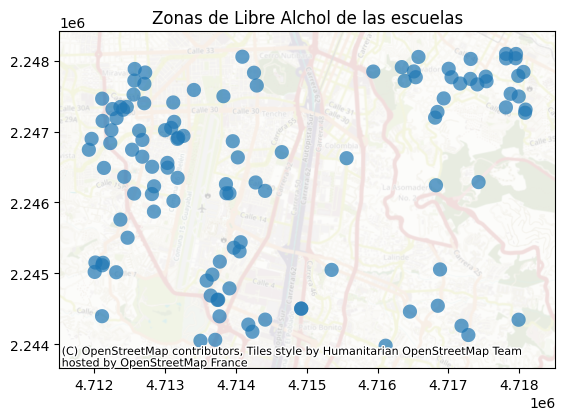

In [ ]:
ax12 = zona_libre_alcohol.cx[4712000:4718000, 2244000:2248000].plot(alpha=0.7)
ctx.add_basemap(ax=ax12, crs=educacion.crs.to_string(), alpha=0.3)
ax12.set_title('Zonas de Libre Alchol de las escuelas')
plt.show()

**Visualizamos las capas**

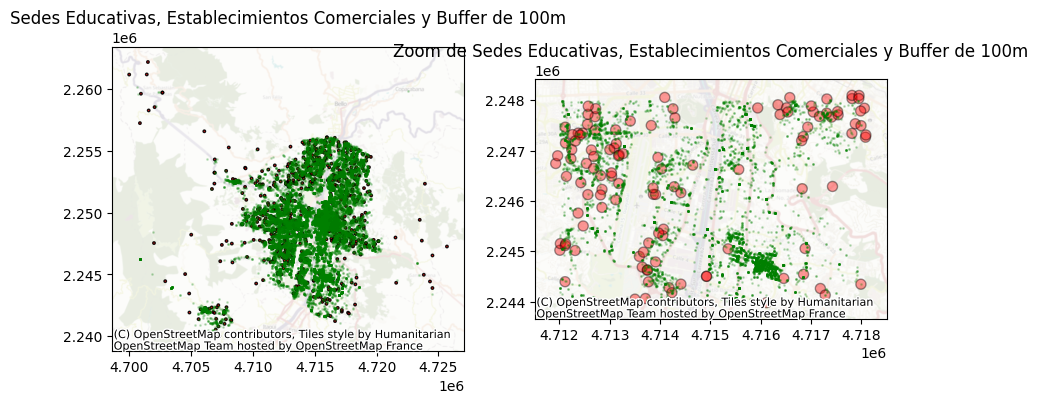

In [ ]:
fig, (ax12, ax13) = plt.subplots(1, 2, figsize=(10,10))
zona_libre_alcohol.plot(ax=ax12, color='red', alpha=0.9, edgecolor='black', markersize=4, zorder=1)
establecimientos_med.plot(ax=ax12, color='green', alpha=0.2, markersize=1, zorder=2)
ctx.add_basemap(ax=ax12, crs=educacion.crs.to_string(), alpha=0.3)
ax12.set_title('Sedes Educativas, Establecimientos Comerciales y Buffer de 100m')


#Hagamos un zoom dentro de [4712000:4718000, 2244000:2248000]
zona_libre_alcohol.cx[4712000:4718000, 2244000:2248000].plot(ax=ax13, color='red', alpha=0.4, edgecolor='black', markersize=4, zorder=1)
establecimientos_med.cx[4712000:4718000, 2244000:2248000].plot(ax=ax13, color='green', alpha=0.2, markersize=1, zorder=2)
ctx.add_basemap(ax=ax13, crs=educacion.crs.to_string(), alpha=0.3)
ax13.set_title('Zoom de Sedes Educativas, Establecimientos Comerciales y Buffer de 100m')

plt.show()

In [ ]:
establecimientos_problema = establecimientos_med.sjoin(zona_libre_alcohol, how='inner', predicate='within')

#Reseteamos index
establecimientos_problema = establecimientos_problema.reset_index(drop=True)

In [ ]:
establecimientos_problema.tail()

,OBJECTID_left,id_contrato,nombre_establecimiento_left,corregimiento,codigociiu,grupo_actividad,comuna,nombre_comuna_left,codigo_barrio_left,nombre_barrio_left,...,dane_sede,longitud_right,latitud_right,cbml,codigo_comuna,nombre_comuna_right,codigo_barrio_right,nombre_barrio_right,geometry_right,buffer_200m
8140,438320,00000000000001931032,FIRE STATION,11,5611,03,None,LAURELES,1110,La Castellana,...,305001022038,-75.605622,6.243409,11100430016,11,Laureles Estadio,1110,La Castellana,POINT (4711785.416 2248598.097),"POLYGON ((4711985.416 2248598.097, 4711984.453..."
8141,438372,00000000000001932156,granizados hot ice,,5630,02,None,BUENOS AIRES,0910,La Milagrosa,...,305001004404,-75.553617,6.235637,09100150007,09,Buenos Aires,0910,La Milagrosa,POINT (4717537.481 2247710.284),"POLYGON ((4717737.481 2247710.284, 4717736.518..."
8142,438372,00000000000001932156,granizados hot ice,,5630,02,None,BUENOS AIRES,0910,La Milagrosa,...,305001026408,-75.553719,6.236220,09100240008,09,Buenos Aires,0910,La Milagrosa,POINT (4717526.537 2247774.851),"POLYGON ((4717726.537 2247774.851, 4717725.574..."
8143,438393,00000000000001932144,ADVIDEOPRO,,5611,03,None,LA CANDELARIA,1019,La Candelaria,...,305001024609,-75.563254,6.248979,10190470008,10,La Candelaria,1019,La Candelaria,POINT (4716477.933 2249191.128),"POLYGON ((4716677.933 2249191.128, 4716676.97 ..."
8144,438451,00000000000001932636,EL PALACIO DE LA NOCHE,06,5630,02,None,DOCE DE OCTUBRE,0609,Picachito,...,105001013013,-75.584731,6.300117,06090200021,06,Doce de Octubre,0609,Picachito,POINT (4714128.686 2254859.125),"POLYGON ((4714328.686 2254859.125, 4714327.723..."


In [ ]:
#Comparemos el número de establecimientos originales con los acutales
print(f"Total de establecimientos comerciales: {establecimientos_med.shape[0]}")
print(f"Total de establecimientos comerciales en áreas protegidas: {establecimientos_problema.shape[0]}")

Total de establecimientos comerciales: 31338
Total de establecimientos comerciales en áreas protegidas: 8145


In [ ]:
# Creamos una figura con subplots en matriz 2x2
fig, ((ax14, ax15), (ax16, ax17)) = plt.subplots(2, 2, figsize=(20, 20))

# Primera fila - Visualización completa
# Gráfico 1 - Todas las áreas
zona_libre_alcohol.plot(ax=ax14, color='red', alpha=0.9, edgecolor='black', markersize=4, zorder=1)
establecimientos_med.plot(ax=ax14, color='green', alpha=0.2, markersize=1, zorder=2)
ctx.add_basemap(ax=ax14, crs=educacion.crs.to_string(), alpha=0.3)
ax14.set_title('Todas las Sedes Educativas y\nEstablecimientos Comerciales', pad=20)

# Gráfico 2 - Áreas problemáticas
zona_libre_alcohol.plot(ax=ax15, color='red', alpha=0.9, edgecolor='black', markersize=4, zorder=1)
establecimientos_problema.plot(ax=ax15, color='green', alpha=0.2, markersize=1, zorder=2)
ctx.add_basemap(ax=ax15, crs=educacion.crs.to_string(), alpha=0.3)
ax15.set_title('Sedes Educativas y\nEstablecimientos en Zona Protegida', pad=20)

# Segunda fila - Visualización con zoom
# Gráfico 3 - Zoom todas las áreas
zona_libre_alcohol.cx[4712000:4718000, 2244000:2248000].plot(ax=ax16, color='red', alpha=0.4, edgecolor='black', markersize=4, zorder=1)
establecimientos_med.cx[4712000:4718000, 2244000:2248000].plot(ax=ax16, color='green', alpha=0.2, markersize=1, zorder=2)
ctx.add_basemap(ax=ax16, crs=educacion.crs.to_string(), alpha=0.3)
ax16.set_title('Zoom: Todas las Sedes y\nEstablecimientos', pad=20)

# Gráfico 4 - Zoom áreas problemáticas
zona_libre_alcohol.cx[4712000:4718000, 2244000:2248000].plot(ax=ax17, color='red', alpha=0.4, edgecolor='black', markersize=4, zorder=1)
establecimientos_problema.cx[4712000:4718000, 2244000:2248000].plot(ax=ax17, color='green', alpha=0.2, markersize=1, zorder=2)
ctx.add_basemap(ax=ax17, crs=educacion.crs.to_string(), alpha=0.3)
ax17.set_title('Zoom: Sedes y Establecimientos\nen Zona Protegida', pad=20)

# Ajustamos el layout
plt.tight_layout()

# Añadimos un título general
fig.suptitle('Análisis de Proximidad: Establecimientos Comerciales y Sedes Educativas',
            fontsize=16, y=1.05)

plt.show()